In [1]:
pip install opencv-python "numpy<2" matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
def add_gaussian_noise(image, mean=0, std=1):
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise 
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image

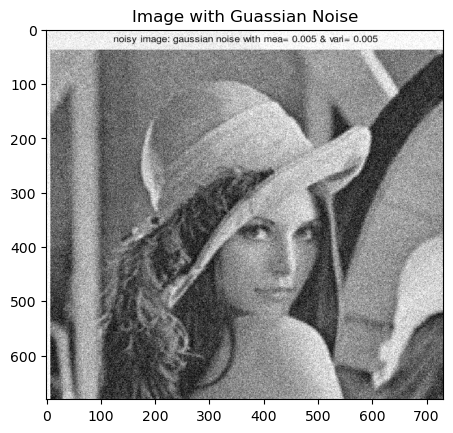

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/Users/230070/Downloads/noisy_image.png', cv2.IMREAD_GRAYSCALE)

noisy_image = add_gaussian_noise(image, mean=0, std=20)

plt.imshow(noisy_image, cmap='gray')
plt.title("Image with Guassian Noise")
plt.show()

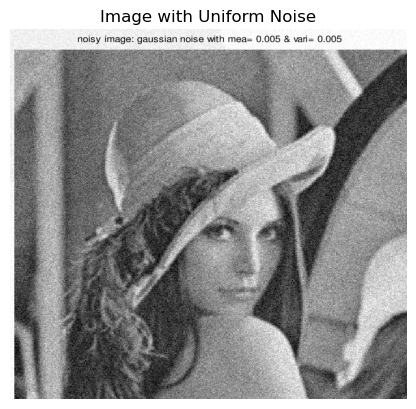

In [6]:
def add_uniform_noise(image, low=-20, high=20):
    noise = np.random.uniform(low, high, image.shape)
    return np.clip(image + noise, 0, 255)

noisy_image = add_uniform_noise(image, low=-20, high=20)

plt.imshow(noisy_image, cmap='gray')
plt.title("Image with Uniform Noise")
plt.axis('off')
plt.show()



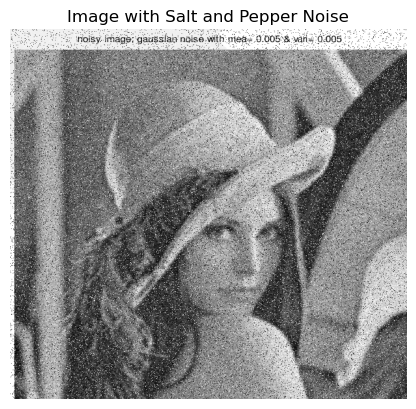

In [7]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = image.copy()
    total = image.size

    num_salt = int(total * salt_prob)
    coords_salt = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords_salt[0], coords_salt[1]] = 255

    num_pepper = int(total * pepper_prob)
    coords_pepper = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords_pepper[0], coords_pepper[1]] = 0
    return noisy

sp_image = add_salt_pepper_noise(image)

plt.imshow(sp_image, cmap='gray')
plt.title("Image with Salt and Pepper Noise")
plt.axis('off')
plt.show()


Apply any specific filtering for denoising

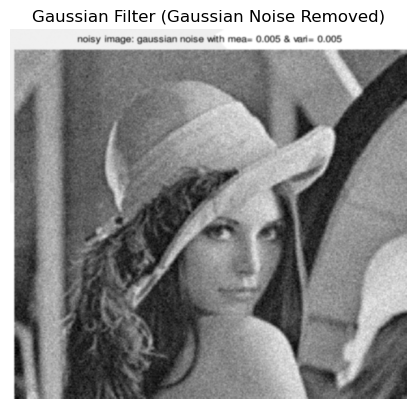

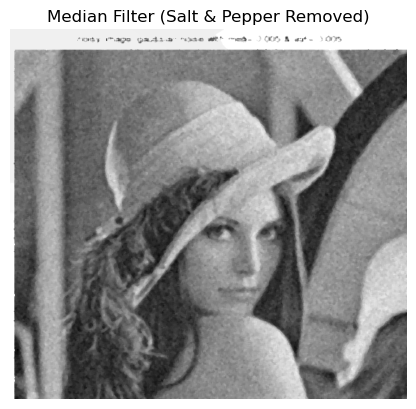

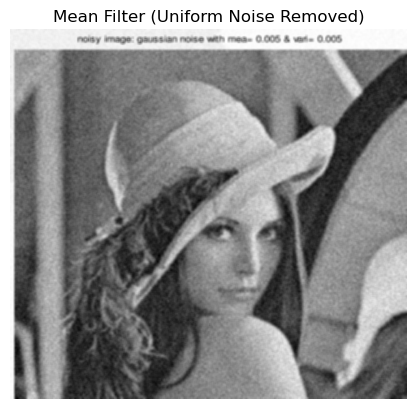

In [8]:
# Gaussian Filter (best for Gaussian noise)
gaussian_noisy = add_gaussian_noise(image) 
gaussian_filtered = cv2.GaussianBlur(gaussian_noisy, (5, 5), 0)

plt.imshow(gaussian_filtered, cmap='gray')
plt.title("Gaussian Filter (Gaussian Noise Removed)")
plt.axis('off')
plt.show()

# Median Filter (best for Salt & Pepper)
median_filtered = cv2.medianBlur(sp_image, 5)

plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filter (Salt & Pepper Removed)")
plt.axis('off')
plt.show()

# Mean Filter (best for Uniform noise)
mean_filtered = cv2.blur(noisy_image, (5, 5))

plt.imshow(mean_filtered, cmap='gray')
plt.title("Mean Filter (Uniform Noise Removed)")
plt.axis('off')
plt.show()

Apply MEASURMENT 

In [12]:
def mse(original,processed):
    return np.mean((original - processed) ** 2)

def psnr(original, processed):
    m = mse(original, processed)
    if m == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(m))

mse_median = mse(image, median_filtered)
psnr_median = psnr(image, median_filtered)

mse_gaussian = mse(image, gaussian_filtered)
psnr_gaussian = psnr(image, gaussian_filtered)

mse_mean = mse(image, mean_filtered)
psnr_mean = psnr(image, mean_filtered)

print("Median filter (Salt and Pepper): ")
print("MSE:", mse_median)
print("PSNR:", psnr_median)

print("\nGuassian filter (Guassian Noise): ")
print("MSE:", mse_gaussian)
print("PSNR:", psnr_gaussian)

print("\nMean filter (Uniform Noise): ")
print("MSE:", mse_mean)
print("PSNR:", psnr_mean)


Median filter (Salt and Pepper): 
MSE: 69.02734973714924
PSNR: 29.74059161630369

Guassian filter (Guassian Noise): 
MSE: 255.59826747328958
PSNR: 24.05522455158309

Mean filter (Uniform Noise): 
MSE: 393.3224205480524
PSNR: 22.183316576751157
